## Практическое занятие 5
## Математический анализ
## Численное решение нелинейных уравнений: nsolve
https://docs.sympy.org/latest/modules/solvers/solvers.html?highlight=nsolve#sympy.solvers.solvers.nsolve

#### Уравнение в форме $f(x)=0$

In [1]:
import numpy as np
import sympy
from sympy import nsolve
import matplotlib.pyplot as plt
%matplotlib inline

### Задача 1
Решить уравнение $𝑥^4−e^x=0$ при $-2 \le x \le 2$, построить график левой части, отметить точки пересечения с осью ОХ.

In [2]:
from sympy.abc import x
import math
def f(x):
  return x ** 4 - math.e ** x

In [3]:
roots = sympy.solve(f(x))
roots

[-0.815553418808960, 1.42961182472556]

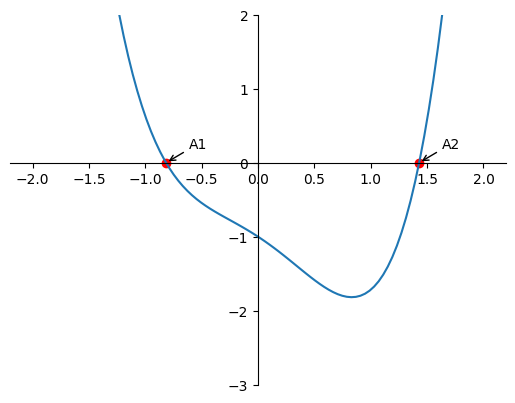

In [4]:
X = np.linspace(-2, 2, 100)
plt.plot(X, f(X))
plt.scatter(roots[0], f(roots[0]), color='red')
plt.scatter(roots[1], f(roots[1]), color='red')
ax = plt.gca()
for i in range(2):
  ax.annotate('A' + str(i + 1), xy=(roots[i], f(roots[i])), xycoords='data',
            xytext=(roots[i] + 0.2, f(roots[i]) + 0.2), textcoords='data',
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"))
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))
plt.ylim(-3, 2)
plt.show()

### Задача 2.
Решить уравнение $\sin^2(2x)=\ln x$ при $0< x \le 3$. Построить графики левой и правой части, отметить точку пересечения графиков.

In [5]:
def f(x):
  return sympy.sin(2 * x) ** 2 - sympy.ln(x)

In [6]:
root1 = sympy.nsolve(f(x), x, 1)
root2 = sympy.nsolve(f(x), x, 2)
root3 = sympy.nsolve(f(x), x, 2.5)
roots = [root1, root2, root3]
roots

[1.30133323382849, 2.08594344788353, 2.50217038800416]

In [7]:
def h(x):
  return np.sin(2 * x) ** 2

In [8]:
def g(x, lib='np'):
  if lib == 'np':
    return np.log(x)
  return math.log(x)

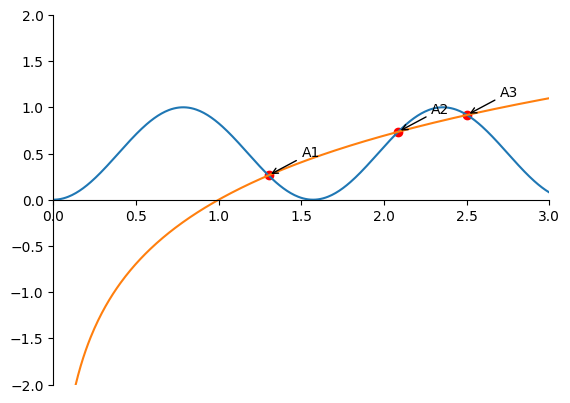

In [9]:
X = np.linspace(0.0001, 3, 400)
plt.plot(X, h(X))
plt.plot(X, g(X))
plt.scatter(roots[0], g(roots[0], 'math'), color='red')
plt.scatter(roots[1], g(roots[1], 'math'), color='red')
plt.scatter(roots[2], g(roots[2], 'math'), color='red')
ax = plt.gca()
for i in range(3):
  ax.annotate('A' + str(i + 1), xy=(roots[i], g(roots[i], 'math')), xycoords='data',
            xytext=(roots[i] + 0.2, g(roots[i], 'math') + 0.2), textcoords='data',
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"))
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))
plt.ylim(-2, 2)
plt.xlim(0, 3)
plt.show()

### Задача 3.
Решить уравнение $\sin^2(2x^2-7x+6)=3/4$ на $[3, 4]$. Построить графики левой и правой части, отметить точки пересечения графиков.

In [10]:
def f(x):
  return sympy.sin(2 * x ** 2 - 7 * x + 6) ** 2 - 3/4

In [11]:
root1 = sympy.nsolve(f(x), x, 3)
root2 = sympy.nsolve(f(x), x, 3.1)
root3 = sympy.nsolve(f(x), x, 3.5)
root4 = sympy.nsolve(f(x), x, 3.7)
roots = [root1, root2, root3, root4]
roots

[3.21863715818210, 3.38722138942523, 3.68072303274915, 3.81186570968780]

In [12]:
def h(x, lib='np'):
  if lib == 'np':
    return np.sin(2 * x ** 2 - 7 * x + 6) ** 2
  return math.sin(2 * x ** 2 - 7 * x + 6) ** 2

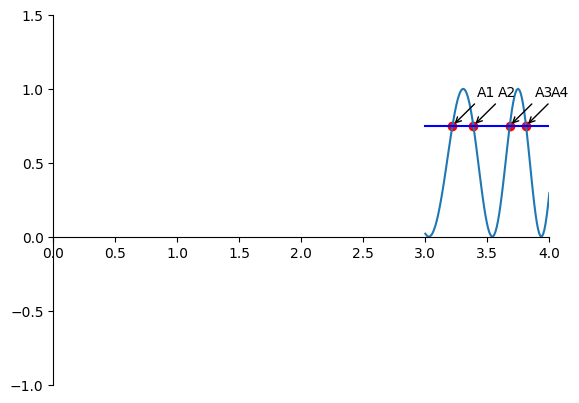

In [13]:
X = np.linspace(3, 4, 100)
plt.plot(X, h(X))
plt.plot(X, np.full_like(X, 3/4), color='blue')
plt.scatter(roots[0], h(roots[0], 'math'), color='red')
plt.scatter(roots[1], h(roots[1], 'math'), color='red')
plt.scatter(roots[2], h(roots[2], 'math'), color='red')
plt.scatter(roots[3], h(roots[3], 'math'), color='red')
ax = plt.gca()
for i in range(4):
  ax.annotate('A' + str(i + 1), xy=(roots[i], h(roots[i], 'math')), xycoords='data',
            xytext=(roots[i] + 0.2, h(roots[i], 'math') + 0.2), textcoords='data',
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"))
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))
plt.ylim(-1, 1.5)
plt.xlim(0, 4)
plt.show()

### Задача 4.
Решить уравнение ${\rm tg}^4(2x^2+1)-10=0$ на интервале $[0, 0.2]$ методом дихотомии. График строить не нужно.

In [39]:
def f(x):
    return np.tan(2 * x ** 2 + 1) ** 4 - 10

In [44]:
def dyhotomy(f, x, y):
    if f(x) * f(y) >= 0:
        raise ValueError
    while (y - x) / 2 > 1e-6:
        point = (x + y) / 2
        if f(point) == 0:
            return point
        elif f(x) * f(point) < 0:
            y = point
        else:
            x = point
    return (x + y) / 2
x = 0.0
y = 0.2
root = dyhotomy(f, x, y)
root

0.17106704711914061

### Задача 5.
Решить систему уравнений
$$
\left\{\begin{matrix}
(x - 1)^2 + (y - 2)^2 + (z + 3)^2 = 25\\
x + y + z = 0\\
-2x + 3y - z = 7
\end{matrix}\right.
$$
начальное приближение (0, 0, 0).
Проверить подстановкой.

In [34]:
x, y, z = sympy.symbols('x y z')
def f(x, y, z):
    return (x - 1) ** 2 + (y - 2) ** 2 + (z + 3) ** 2

In [35]:
def g(x, y, z):
  return x + y + z

In [36]:
def h(x, y, z):
  return -2 * x + 3 * y - z

In [37]:
root = sympy.nsolve((sympy.Eq(f(x, y, z), 25), sympy.Eq(g(x, y, z), 0), sympy.Eq(h(x, y, z), 7)), (x, y, z), (0, 0, 0))
root

Matrix([
[-2.08606699924184],
[ 1.22848325018954],
[0.857583749052298]])

In [38]:
x0, y0, z0 = root
f(x0, y0, z0) == 25 and g(x0, y0, z0) == 0 and h(x0, y0, z0) == 7

False

### Индивидуальное задание
Построить графики функций $f(x)$ и $g(x)$, уточнить координаты точек пересечения, решая численно соответствующее уравнение. На  графике отметить и подписать буквами $А_1$, $A_2$, ... точки пересечения графиков.  

In [ ]:
def f(x):
  return - (x ** 2) / 2 - 7 * x / 2 - 12

In [ ]:
def g(x):
  return x ** 2 + 4 * x - 12

In [ ]:
def h(x):
  return f(x) - g(x)
roots = sympy.solve(h(x))
roots

[-5, 0]

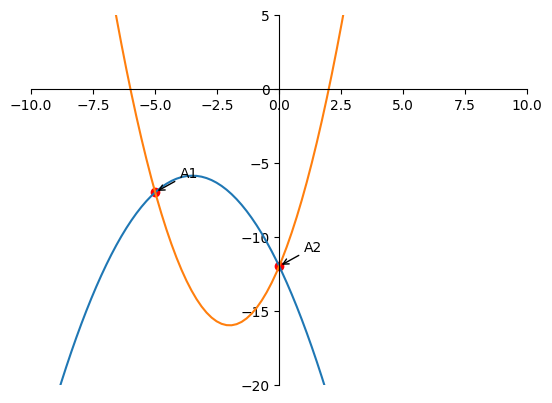

In [ ]:
X = np.linspace(-10, 10, 100)
plt.plot(X, f(X))
plt.plot(X, g(X))
plt.scatter(roots[0], f(roots[0]), color='red')
plt.scatter(roots[1], f(roots[1]), color='red')
ax = plt.gca()
for i in range(2):
  ax.annotate('A' + str(i + 1), xy=(roots[i], g(roots[i])), xycoords='data',
            xytext=(roots[i] + 1, g(roots[i]) + 1), textcoords='data',
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"))
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))
plt.ylim(-20, 5)
plt.xlim(-10, 10)
plt.show()